In [1]:
from sklearn import preprocessing


def Standardize(X):
    scaler = preprocessing.StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled

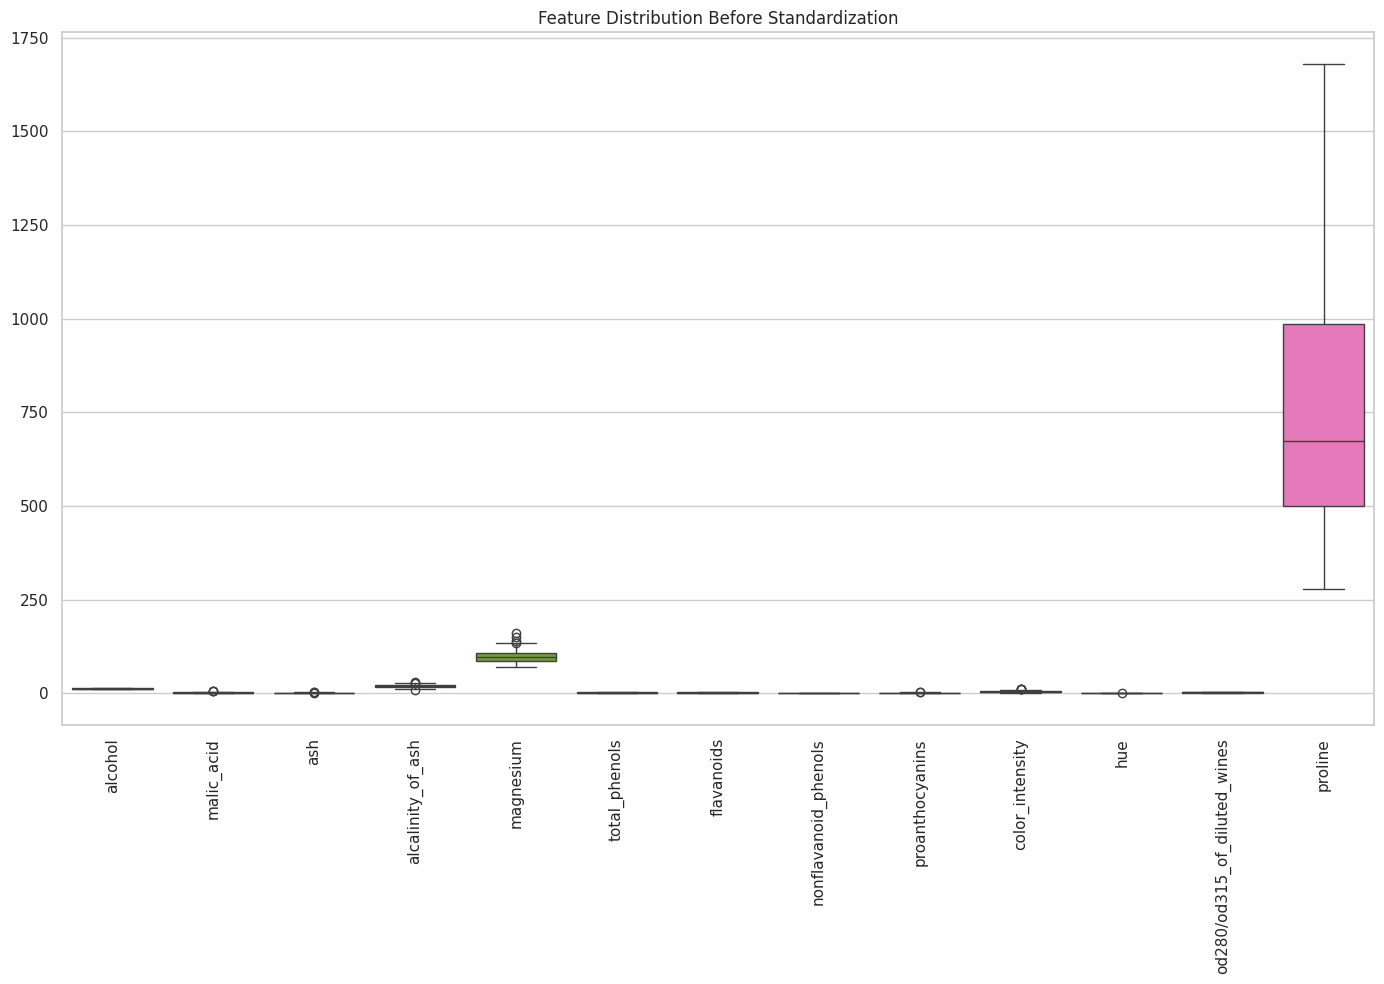

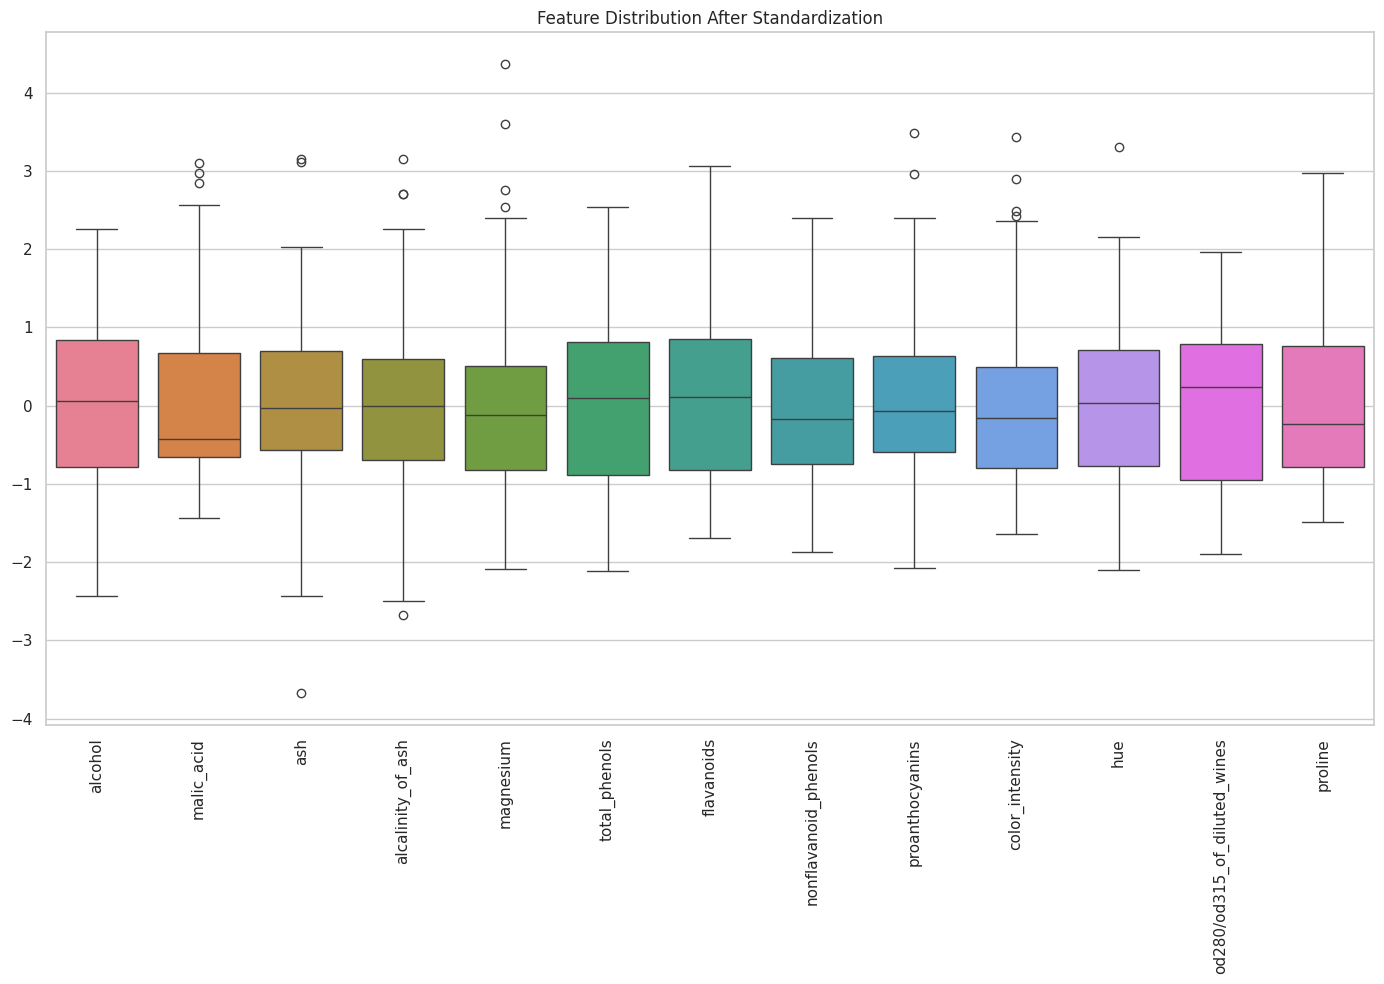

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine


X, _ = load_wine(return_X_y=True)
feature_names = load_wine().feature_names

X_scaled = Standardize(X)

X_df = pd.DataFrame(X, columns=feature_names)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)


sns.set(style="whitegrid")

plt.figure(figsize=(14, 10))
sns.boxplot(data=X_df)
plt.title("Feature Distribution Before Standardization")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.boxplot(data=X_scaled_df)
plt.title("Feature Distribution After Standardization")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
from sklearn import decomposition

def Apply_PCA(X, n_components, random_state):
    pca = decomposition.PCA(
        n_components=n_components,
        random_state=random_state
    )
    X_pca = pca.fit_transform(X)

    return X_pca, pca

***Full PCA: Transform All Features & Show All Components***

In [5]:
from sklearn.datasets import load_wine

X, _ = load_wine(return_X_y=True)

X_scaled = Standardize(X)

X_pca, pca = Apply_PCA(X_scaled, n_components=None, random_state=2)


print("Original shape:", X_scaled.shape)
print("PCA-transformed shape:", X_pca.shape)
print("\nExplained variance ratio of components:", pca.explained_variance_ratio_)

Original shape: (178, 13)
PCA-transformed shape: (178, 13)

Explained variance ratio of components: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


***Cumulative Variance Explained by PCA Components***

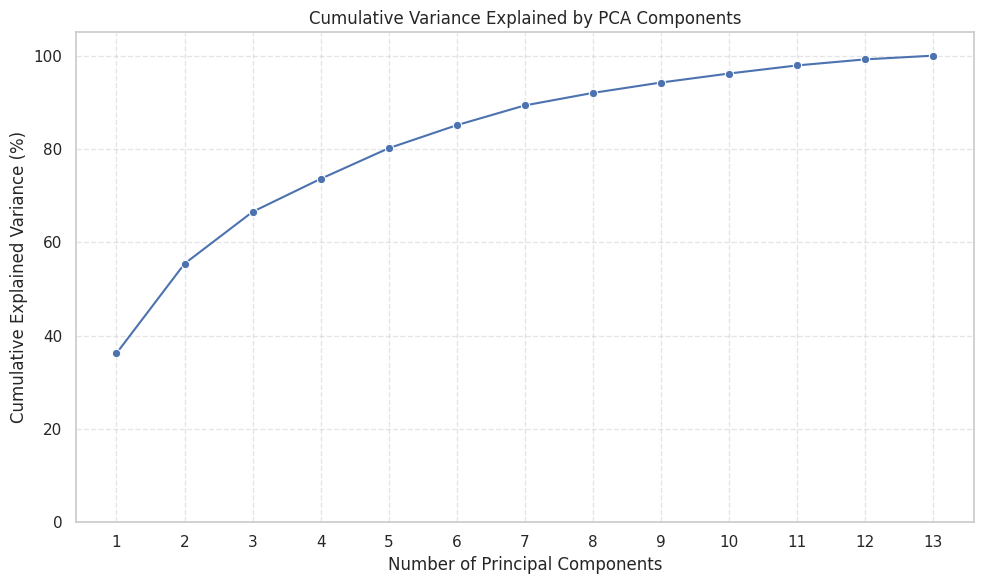

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


X, _ = load_wine(return_X_y=True)

X_scaled = Standardize(X)

_, pca = Apply_PCA(X_scaled, n_components=None, random_state=2)

cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100  # convert to percent
components = np.arange(1, len(cumulative_var) + 1)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x=components, y=cumulative_var, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Variance Explained by PCA Components")
plt.xticks(components)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

***Reduced PCA: Retain 80% Variance***

In [7]:
from sklearn.datasets import load_wine

X, _ = load_wine(return_X_y=True)

X_scaled = Standardize(X)

X_pca, pca = Apply_PCA(X_scaled, n_components=0.8, random_state=2)


print("Original shape:", X_scaled.shape)
print("PCA-transformed shape:", X_pca.shape)
print("\nExplained variance ratio of components:", pca.explained_variance_ratio_)


Original shape: (178, 13)
PCA-transformed shape: (178, 5)

Explained variance ratio of components: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294]


In [8]:
from sklearn import cluster

def K_Means(X, n_clusters, random_state):
    model = cluster.KMeans(
        n_clusters=n_clusters,
        random_state=random_state
    )
    model.fit(X)

    return model

***K-Means Clustering in 2D PCA Space***

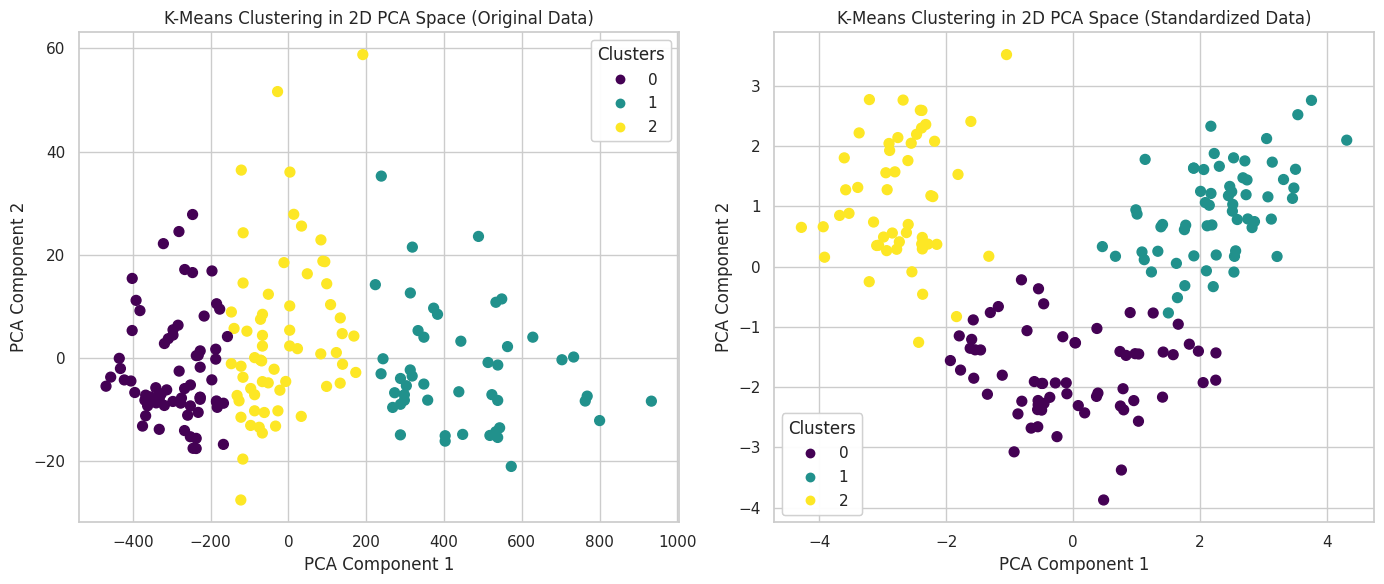

In [9]:
#!/usr/bin/env python3

import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


X, _ = load_wine(return_X_y=True)

model = K_Means(X, n_clusters=3, random_state=2)
labels = model.labels_

X_orig_2d, _ = Apply_PCA(X, n_components=2, random_state=2)

X_scaled = Standardize(X)
model_scaled = K_Means(X_scaled, n_clusters=3, random_state=2)
labels_scaled = model_scaled.labels_

X_scaled_2d, _ = Apply_PCA(X_scaled, n_components=2, random_state=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data
scatter0 = axes[0].scatter(X_orig_2d[:, 0], X_orig_2d[:, 1], c=labels, cmap='viridis', s=50)
axes[0].set_title('K-Means Clustering in 2D PCA Space (Original Data)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
legend0 = axes[0].legend(*scatter0.legend_elements(), title="Clusters")
axes[0].add_artist(legend0)

# Standardized data
scatter1 = axes[1].scatter(X_scaled_2d[:, 0], X_scaled_2d[:, 1], c=labels_scaled, cmap='viridis', s=50)
axes[1].set_title('K-Means Clustering in 2D PCA Space (Standardized Data)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
legend1 = axes[1].legend(*scatter1.legend_elements(), title="Clusters")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()


***K-Means Clustering Visualized in 3D PCA Space***

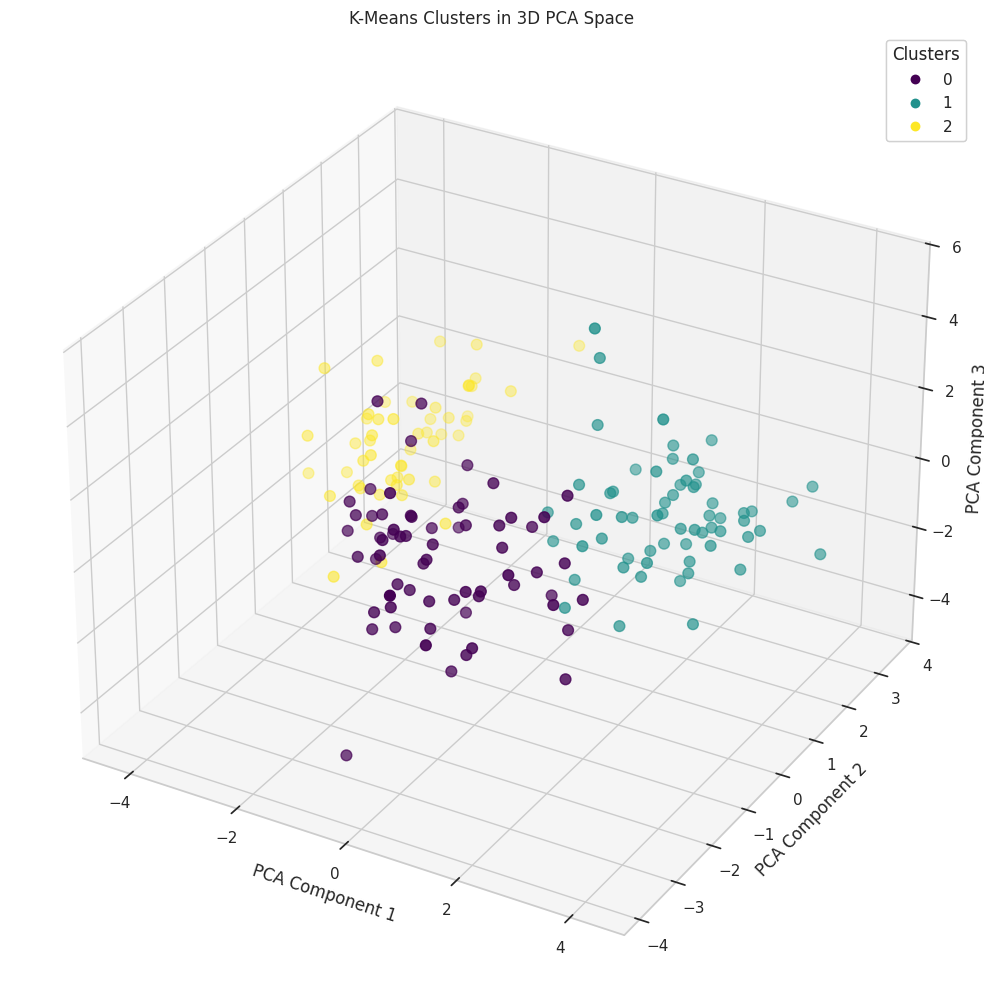

In [10]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


X, _ = load_wine(return_X_y=True)

X_scaled = Standardize(X)

X_3d, _ = Apply_PCA(X_scaled, n_components=3, random_state=2)

model = K_Means(X_scaled, n_clusters=3, random_state=2)
labels = model.labels_

fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
    c=labels, cmap='viridis', s=60, depthshade=True
)

ax.set_title("K-Means Clusters in 3D PCA Space")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [11]:
from sklearn import metrics

def optimal_k(X, max_clusters, random_state):
    """Calculates the optimal k for K-Means clustering."""
    ks = []
    inertia_values = []
    silhouette_values = []

    for k in range(2, max_clusters + 1):
        model = K_Means(X, n_clusters=k, random_state=random_state)

        ks.append(k)
        inertia_values.append(model.inertia_)
        silhouette_values.append(
            metrics.silhouette_score(X, model.labels_)
        )

    return ks, inertia_values, silhouette_values

***K-Means Clustering for Various k Values***

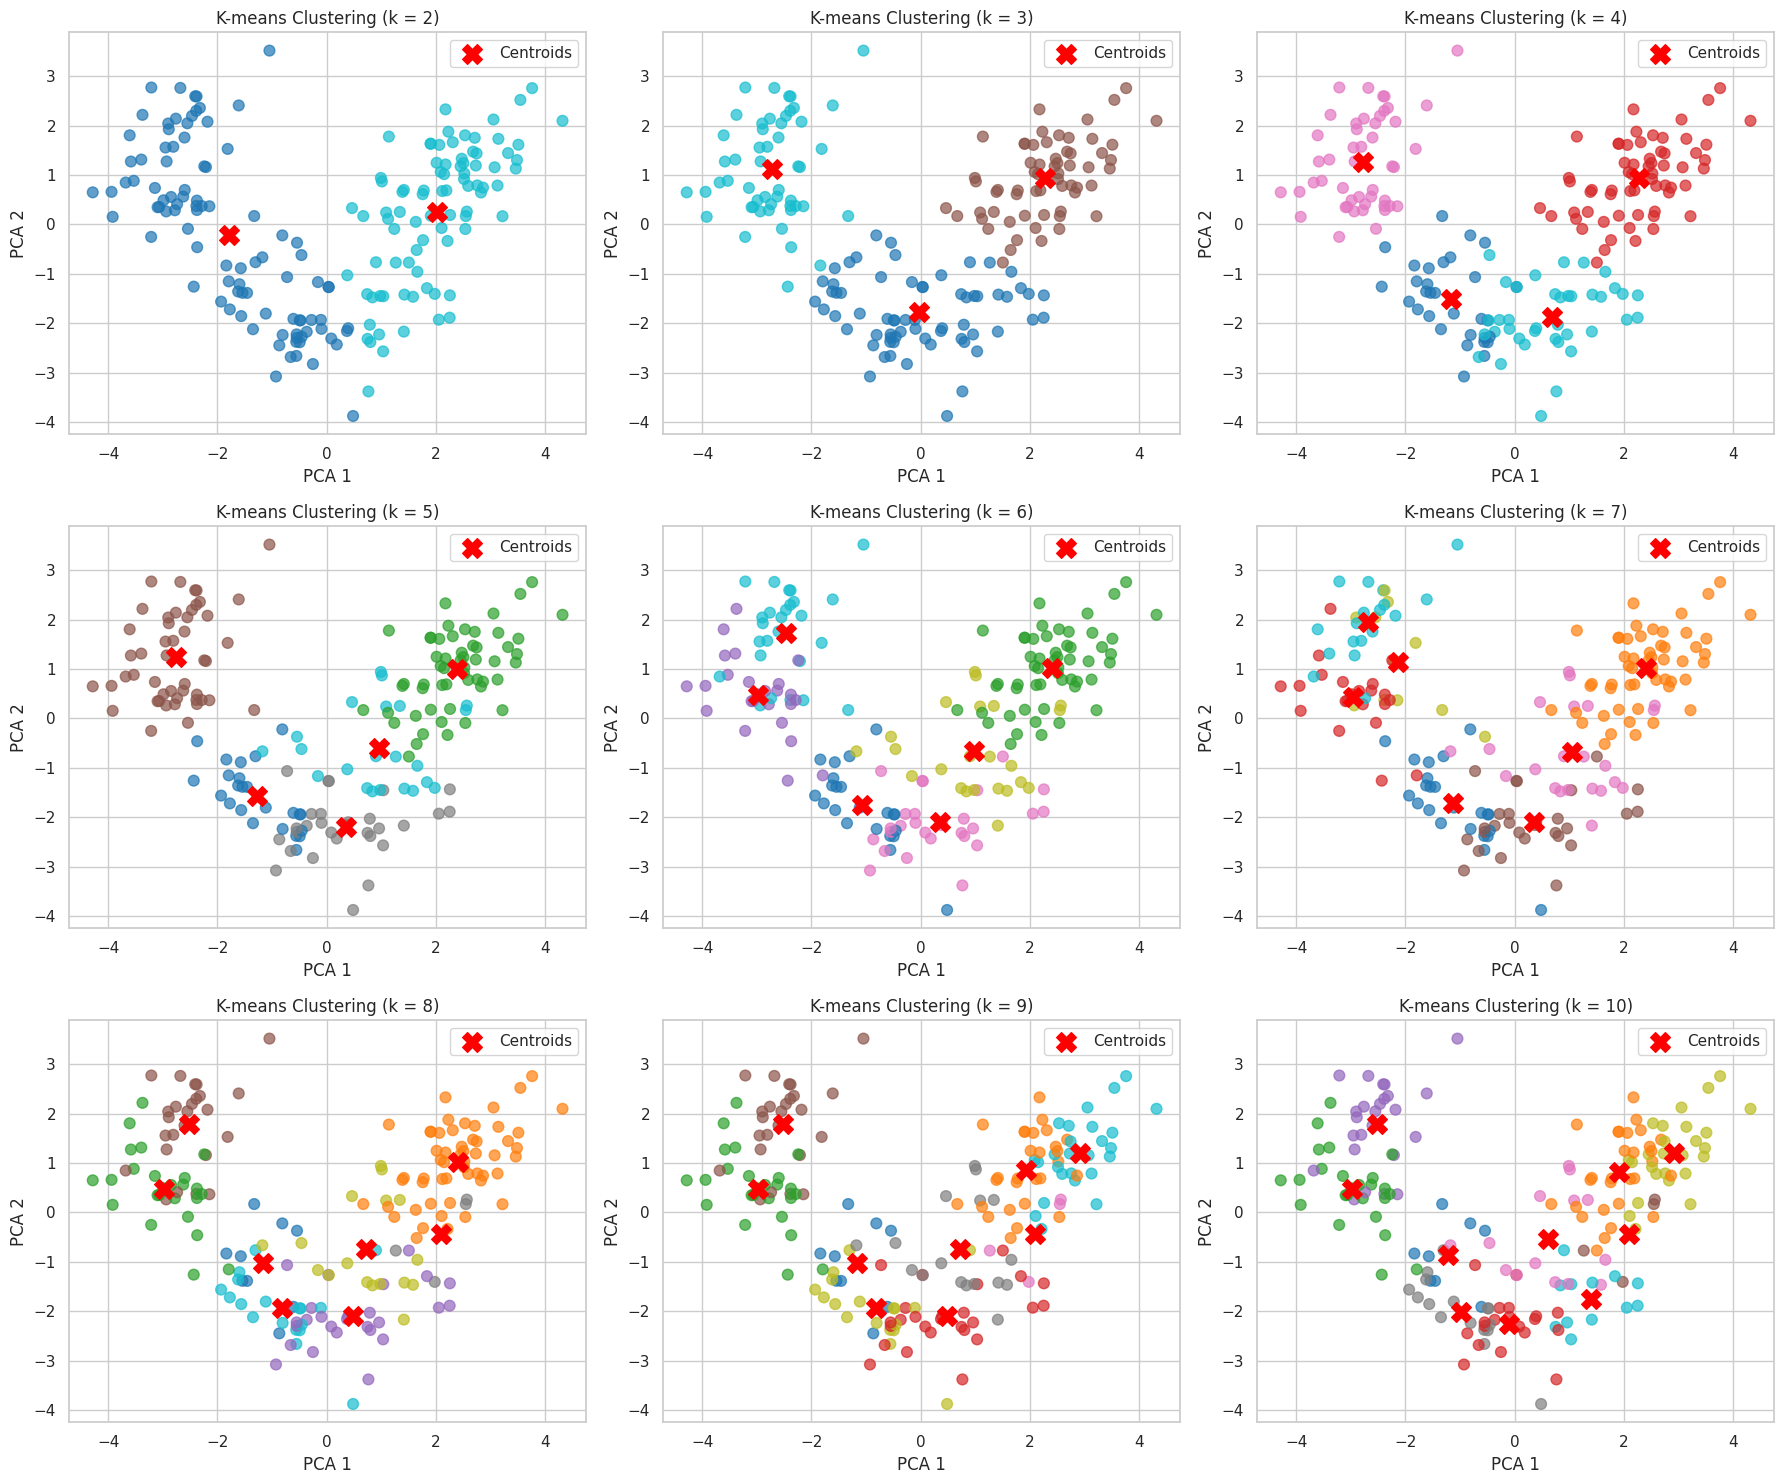

In [12]:
#!/usr/bin/env python3

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
import math


X, _ = load_wine(return_X_y=True)
X_scaled = Standardize(X)

ks, _, _ = optimal_k(X_scaled, max_clusters=10, random_state=2)

X_pca, pca_model = Apply_PCA(X_scaled, n_components=2, random_state=2)

cols = 3
rows = math.ceil(len(ks)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows), squeeze=False)
sns.set(style="whitegrid")

for idx, k in enumerate(ks):
    row, col = divmod(idx, cols)
    ax = axes[row, col]

    model = K_Means(X_scaled, n_clusters=k, random_state=2)
    labels = model.labels_
    centroids_pca = pca_model.transform(model.cluster_centers_)

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=60, alpha=0.7)

    centroid_plot = ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                               c='red', s=200, marker='X', label='Centroids')

    ax.set_title(f"K-means Clustering (k = {k})")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend(handles=[centroid_plot])

for idx in range(len(ks), rows*cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

***Determining the Optimal Number of Clusters k***

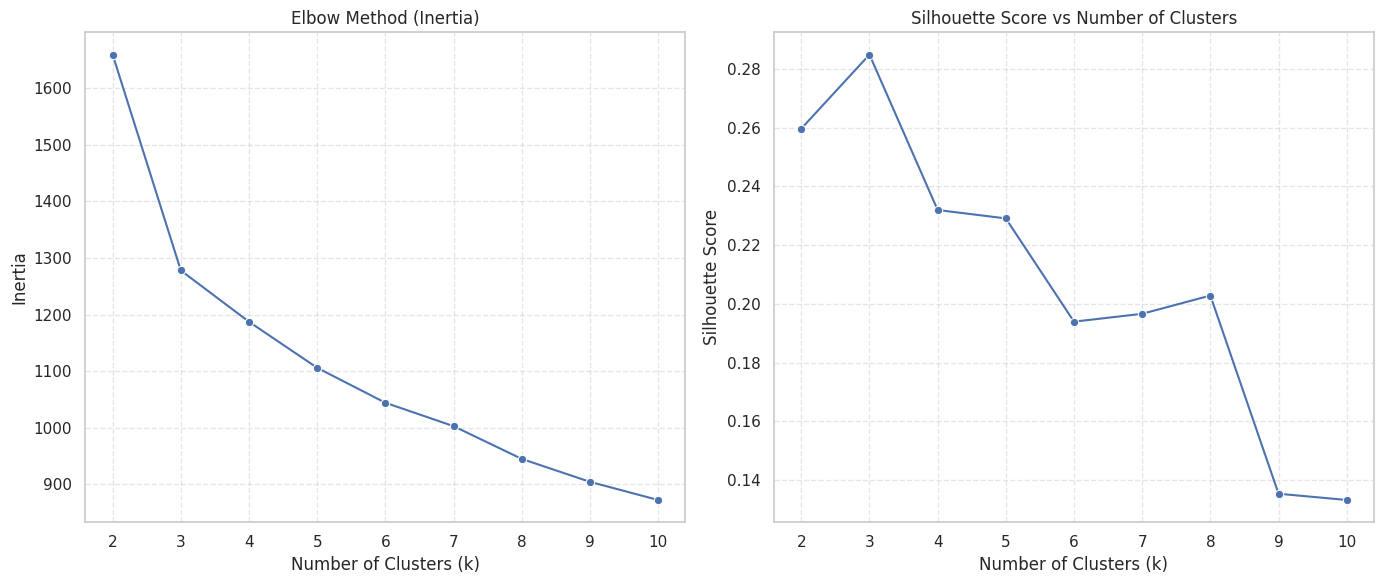

In [13]:
#!/usr/bin/env python3

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


X, _ = load_wine(return_X_y=True)
X_scaled = Standardize(X)

ks, inertia_values, silhouette_values = optimal_k(
    X_scaled, max_clusters=10, random_state=2
)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.lineplot(
    x=ks,
    y=inertia_values,
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(ks)
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.lineplot(
    x=ks,
    y=silhouette_values,
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Silhouette Score vs Number of Clusters")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(ks)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:

from sklearn import cluster
from sklearn import metrics


def Agglomerative_Clustering(X, n_clusters, random_state, n_components,
                              use_pca_data=True):

    if use_pca_data:
        X_used, _ = Apply_PCA(X, n_components, random_state)
    else:
        X_used = X

    model = cluster.AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward'
    )
    model.fit(X_used)

    if n_clusters > 1:
        score = metrics.silhouette_score(X_used, model.labels_)
    else:
        score = None

    return model, X_used, score

***Agglomerative Clustering Results on PCA-Reduced and Original Wine Data***

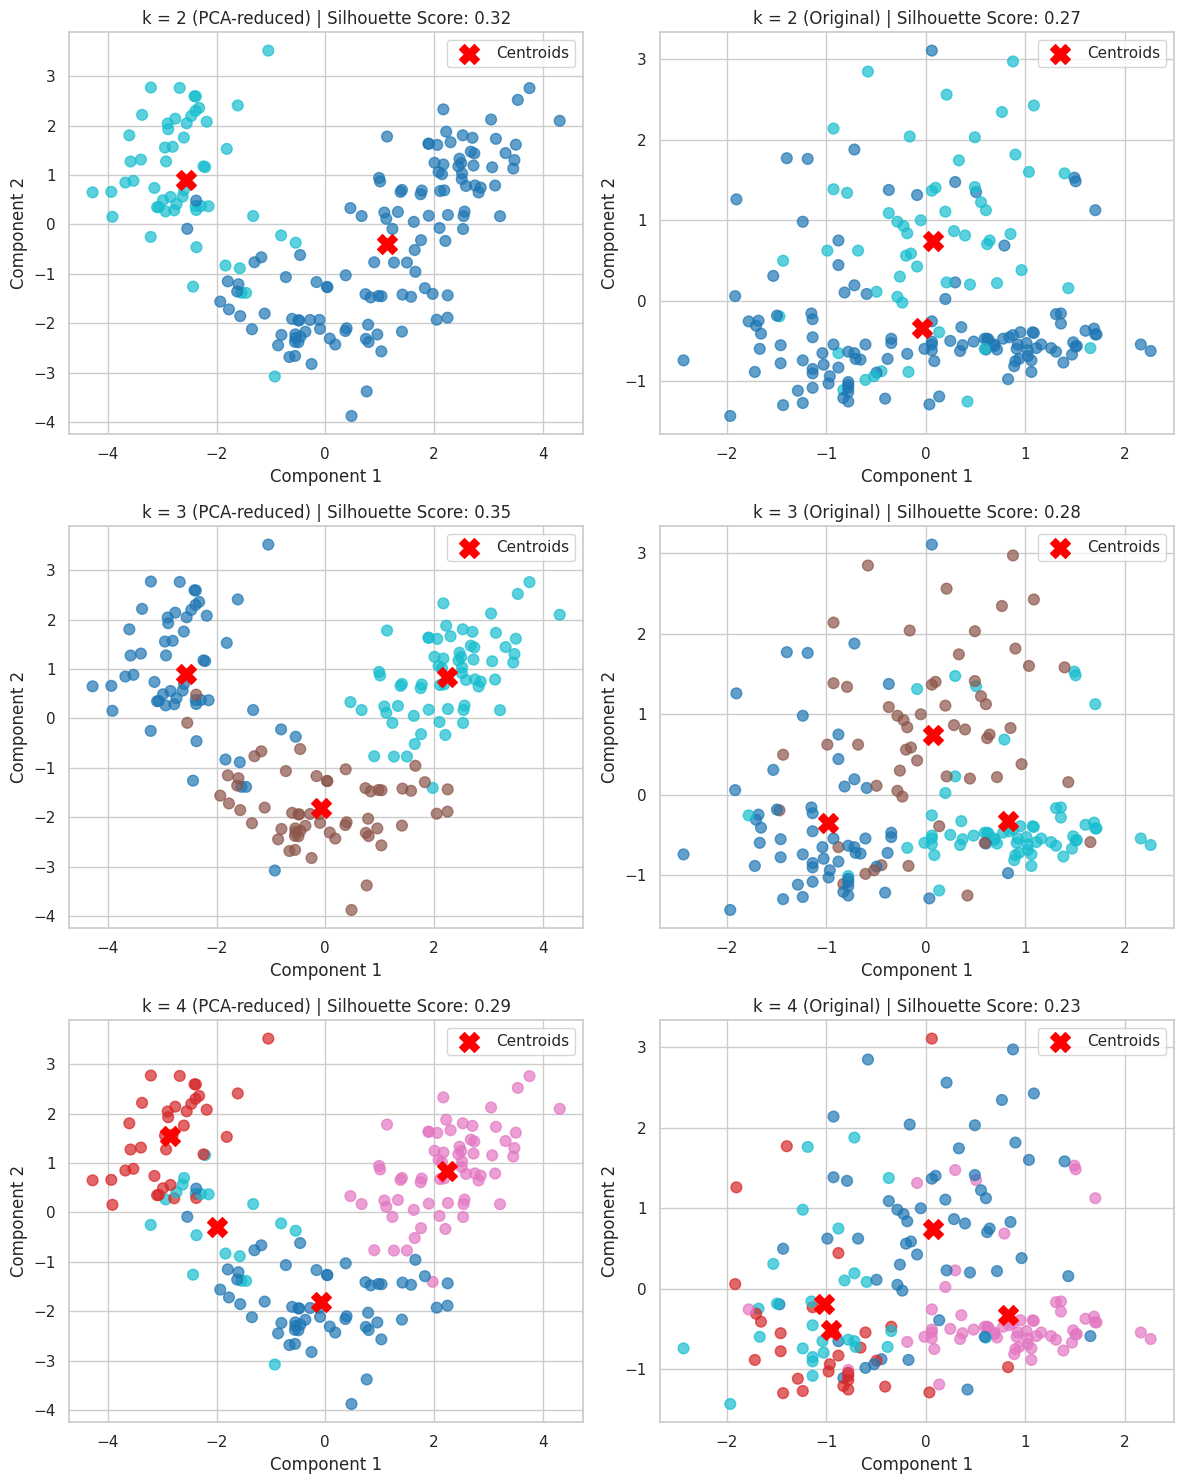

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
import numpy as np


X, _ = load_wine(return_X_y=True)
X_scaled = Standardize(X)

ks = [2, 3, 4]

cols = 2
rows = len(ks)
fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows), squeeze=False)
sns.set(style="whitegrid")

for row_idx, k in enumerate(ks):
    for col_idx, use_pca in enumerate([True, False]):
        ax = axes[row_idx, col_idx]

        model, X_used, score = Agglomerative_Clustering(
            X_scaled, n_clusters=k, random_state=2, n_components=5, use_pca_data=use_pca
        )

        labels = model.labels_

        ax.scatter(X_used[:, 0], X_used[:, 1], c=labels, cmap='tab10', s=60, alpha=0.7)

        centroids = np.array([X_used[labels == i].mean(axis=0) for i in range(k)])
        ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

        data_type = "PCA-reduced" if use_pca else "Original"
        score_text = f"Silhouette Score: {score:.2f}" if score is not None else ""
        ax.set_title(f"k = {k} ({data_type}) | {score_text}")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.legend()

plt.tight_layout()
plt.show()

***Dendrogram***

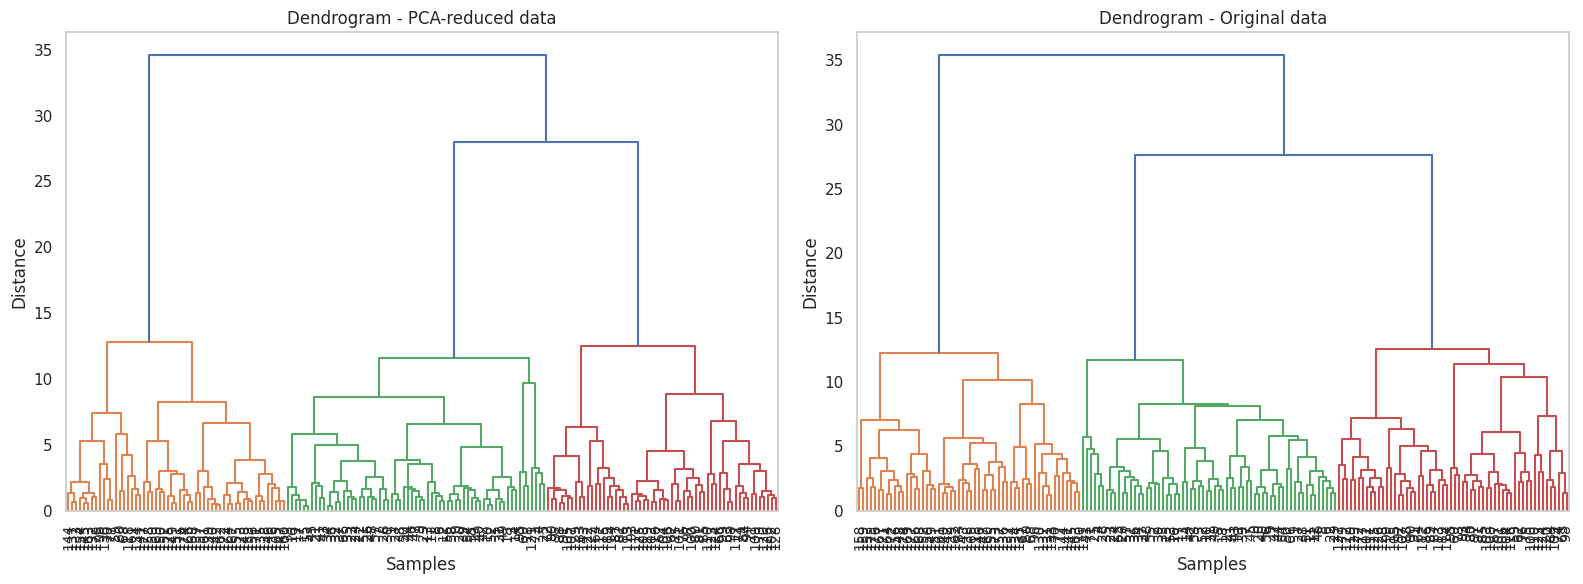

In [16]:


import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from scipy.cluster.hierarchy import linkage, dendrogram


X, _ = load_wine(return_X_y=True)
X_scaled = Standardize(X)

X_pca, _ = Apply_PCA(X_scaled, n_components=5, random_state=2)

Z_pca = linkage(X_pca, method='ward')
Z_original = linkage(X_scaled, method='ward')


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dendrogram(
    Z_pca,
    truncate_mode='level',
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    ax=axes[0],
    color_threshold=None
)
axes[0].set_title("Dendrogram - PCA-reduced data")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Distance")
axes[0].grid(False)
axes[0].set_facecolor('white')

dendrogram(
    Z_original,
    truncate_mode='level',
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    ax=axes[1],
    color_threshold=None
)
axes[1].set_title("Dendrogram - Original data")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Distance")
axes[1].grid(False)
axes[1].set_facecolor('white')

plt.tight_layout()
plt.show()